<a href="https://colab.research.google.com/github/shijithpulikkal/Exploratory-Data-Analysis/blob/main/01_netflix_eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

In [7]:
from google.colab import drive
drive.mount('/content/drive')
df = pd.read_csv('/content/drive/My Drive/Colab Notebooks/EDA/netflix_titles.csv')
df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [5]:
df.shape

(8807, 12)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [9]:
df.describe(include='all')

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
count,8807,8807,8807,6173,7982,7976,8797,8807.000000,8803,8804,8807,8807
unique,8807,2,8807,4528,7692,748,1767,NaN,17,220,514,8775
top,s8807,Movie,Zubaan,Rajiv Chilaka,David Attenborough,United States,"January 1, 2020",NaN,TV-MA,1 Season,"Dramas, International Movies","Paranormal activity at a lush, abandoned prope..."
freq,1,6131,1,19,19,2818,109,NaN,3207,1793,362,4
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2014.180198,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.819312,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1925.000000,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2013.000000,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2017.000000,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2019.000000,NaN,NaN,NaN,NaN


**2. Data Cleaning**

In [10]:
# Check missing values
df.isnull().sum().sort_values(ascending=False)

,0
director,2634
country,831
cast,825
date_added,10
rating,4
duration,3
show_id,0
type,0
title,0
release_year,0


In [11]:
# Fill categorical nulls with 'Unknown'
for col in ['director', 'cast', 'country']:
    df[col] = df[col].fillna('Unknown')

# Rating and duration have very few nulls - drop those rows
df = df.dropna(subset=['rating', 'duration'])

# date_added - drop rows where it's missing (small number)
df = df.dropna(subset=['date_added'])

df.isnull().sum()

,0
show_id,0
type,0
title,0
director,0
cast,0
country,0
date_added,0
release_year,0
rating,0
duration,0


In [12]:
# Convert date_added to datetime
df['date_added'] = pd.to_datetime(df['date_added'].str.strip())
df['year_added'] = df['date_added'].dt.year
df['month_added'] = df['date_added'].dt.month_name()

df[['date_added', 'year_added', 'month_added']].head()

,date_added,year_added,month_added
0,2021-09-25,2021,September
1,2021-09-24,2021,September
2,2021-09-24,2021,September
3,2021-09-24,2021,September
4,2021-09-24,2021,September


In [13]:
# Split duration into numeric value + unit
df['duration_value'] = df['duration'].str.extract('(\d+)').astype(float)
df['duration_unit'] = df['duration'].apply(lambda x: 'Season' if 'Season' in x else 'Minutes')

df[['duration', 'duration_value', 'duration_unit']].head()

<>:2: SyntaxWarning: invalid escape sequence '\d'
<>:2: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_1934/3147114666.py:2: SyntaxWarning: invalid escape sequence '\d'
  df['duration_value'] = df['duration'].str.extract('(\d+)').astype(float)


,duration,duration_value,duration_unit
0,90 min,90.0,Minutes
1,2 Seasons,2.0,Season
2,1 Season,1.0,Season
3,1 Season,1.0,Season
4,2 Seasons,2.0,Season


In [14]:
# Remove exact duplicates if any
df = df.drop_duplicates()
df.shape

(8790, 16)

**3. Univariate Analysis**

/tmp/ipykernel_1934/1567995426.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='type', palette='Set2')


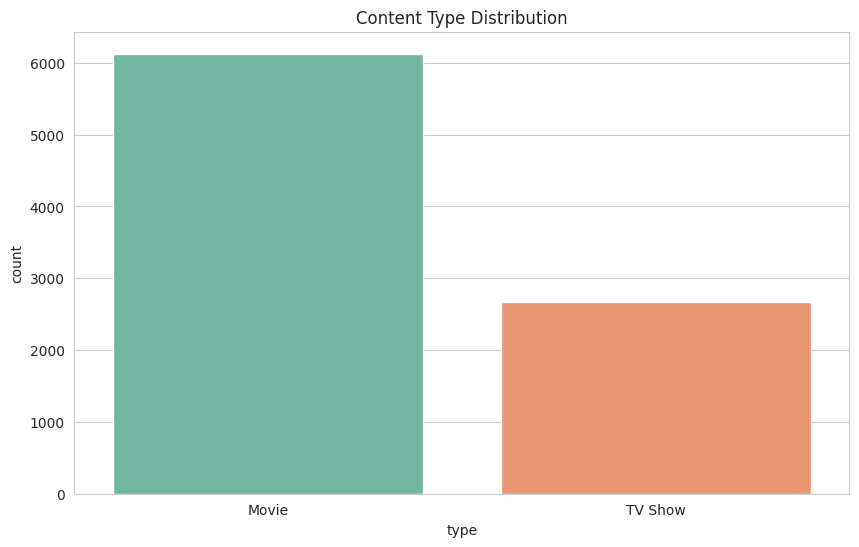

In [15]:
# Movie vs TV Show count
sns.countplot(data=df, x='type', palette='Set2')
plt.title('Content Type Distribution')
plt.show()

/tmp/ipykernel_1934/1419954065.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y='rating', order=df['rating'].value_counts().index, palette='viridis')


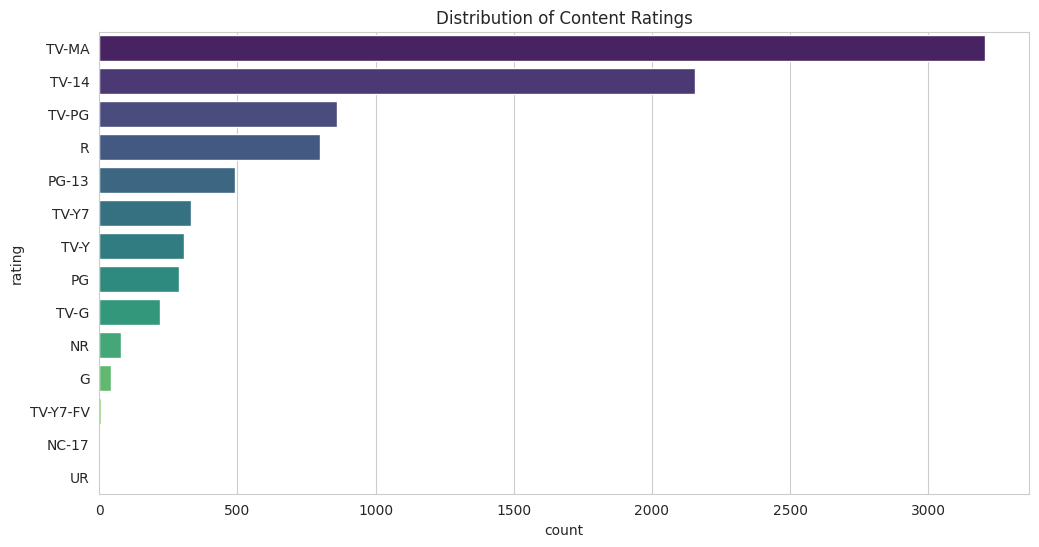

In [16]:
# Rating distribution
plt.figure(figsize=(12,6))
sns.countplot(data=df, y='rating', order=df['rating'].value_counts().index, palette='viridis')
plt.title('Distribution of Content Ratings')
plt.show()

/tmp/ipykernel_1934/2117488221.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_countries.values, y=top_countries.index, palette='mako')


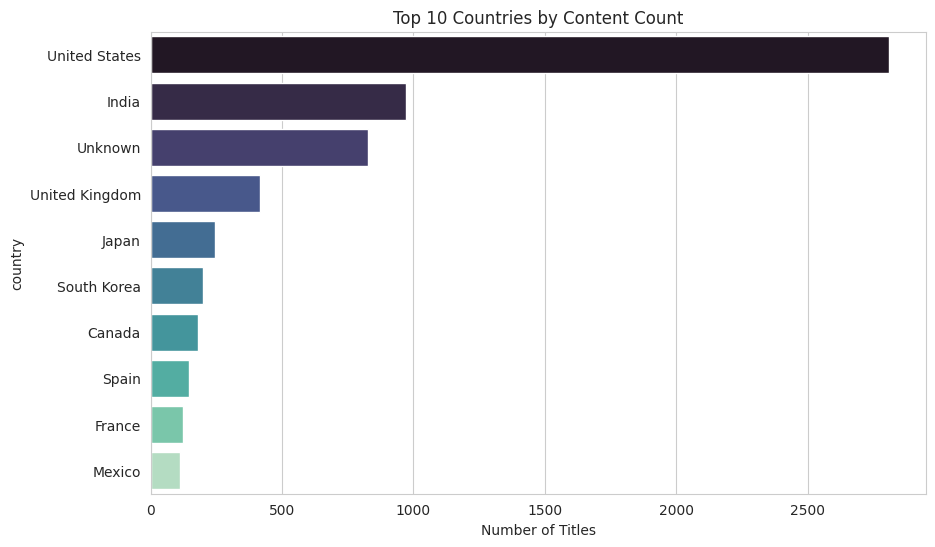

In [17]:
# Top 10 countries
top_countries = df['country'].value_counts().head(10)
sns.barplot(x=top_countries.values, y=top_countries.index, palette='mako')
plt.title('Top 10 Countries by Content Count')
plt.xlabel('Number of Titles')
plt.show()

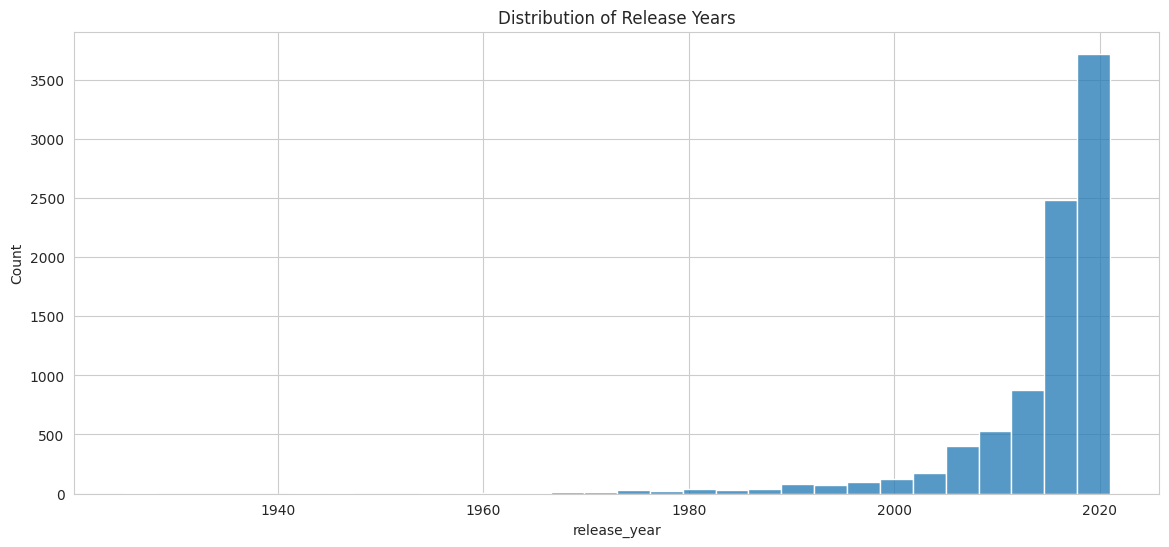

In [18]:
# Release year distribution
plt.figure(figsize=(14,6))
sns.histplot(df['release_year'], bins=30, kde=False)
plt.title('Distribution of Release Years')
plt.show()

**4. Bivariate / Multivariate Analysis**

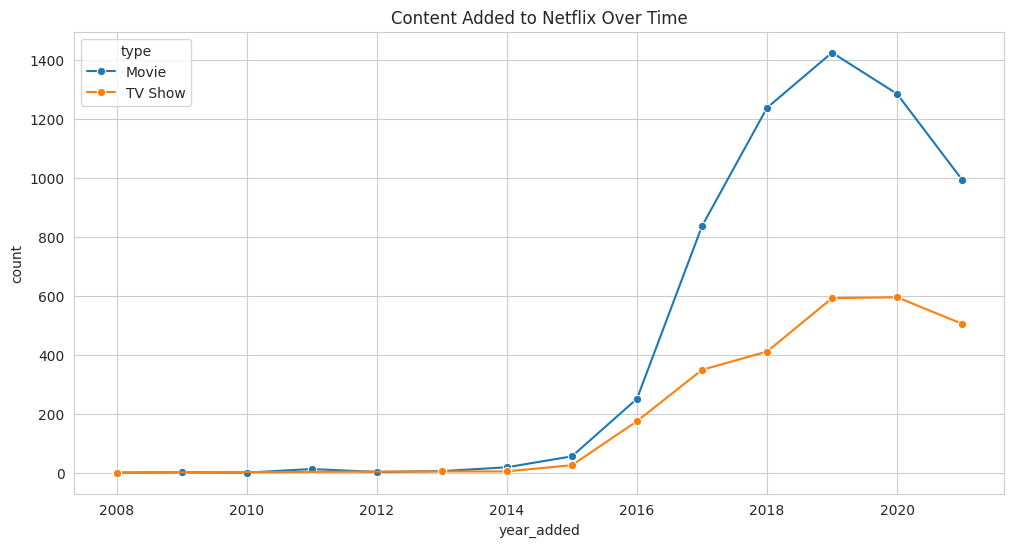

In [19]:
# Movies vs TV Shows added per year
year_type = df.groupby(['year_added', 'type']).size().reset_index(name='count')

plt.figure(figsize=(12,6))
sns.lineplot(data=year_type, x='year_added', y='count', hue='type', marker='o')
plt.title('Content Added to Netflix Over Time')
plt.show()

/tmp/ipykernel_1934/1475475973.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_genres.values, y=top_genres.index, palette='crest')


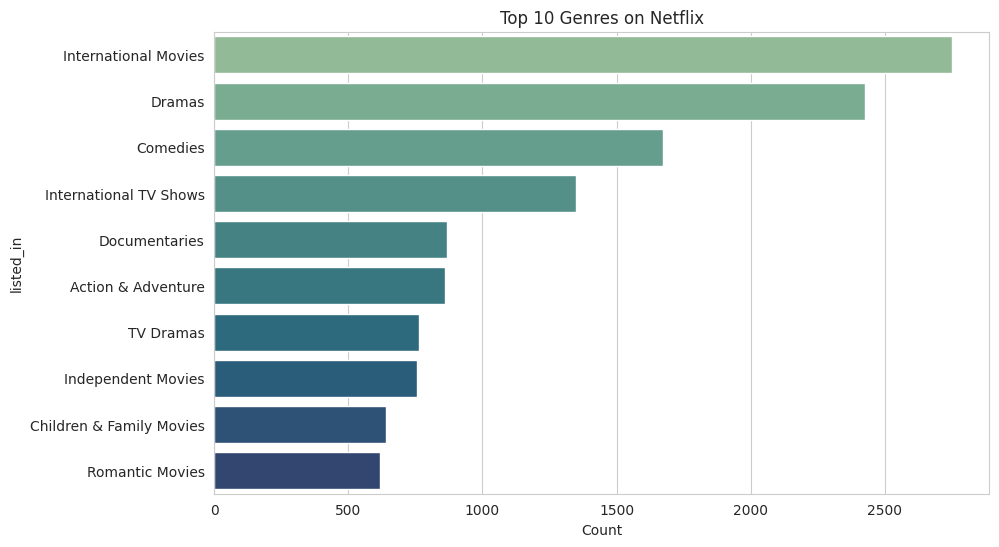

In [20]:
# Top genres - listed_in is comma separated
from collections import Counter

genres = df['listed_in'].str.split(', ').explode()
top_genres = genres.value_counts().head(10)

sns.barplot(x=top_genres.values, y=top_genres.index, palette='crest')
plt.title('Top 10 Genres on Netflix')
plt.xlabel('Count')
plt.show()

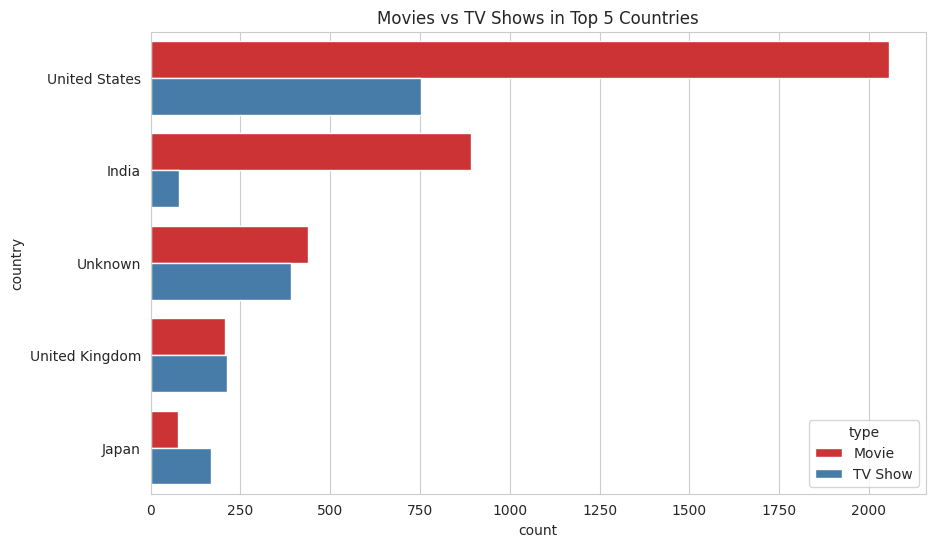

In [21]:
# Countries: Movies vs TV Shows (top 5 countries only)
top5 = df['country'].value_counts().head(5).index
subset = df[df['country'].isin(top5)]

plt.figure(figsize=(10,6))
sns.countplot(data=subset, y='country', hue='type', order=top5, palette='Set1')
plt.title('Movies vs TV Shows in Top 5 Countries')
plt.show()

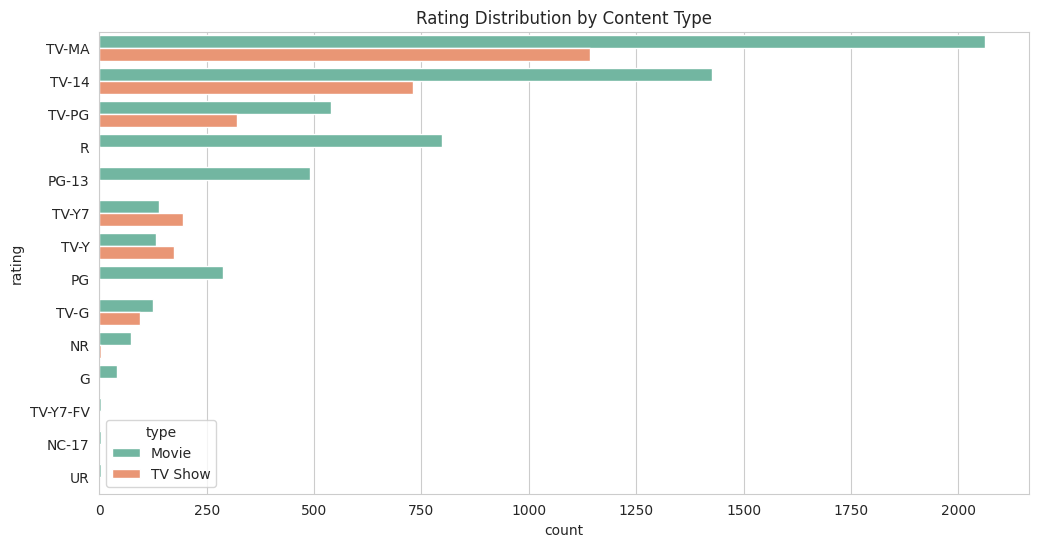

In [22]:
# Rating distribution split by type
plt.figure(figsize=(12,6))
sns.countplot(data=df, y='rating', hue='type', order=df['rating'].value_counts().index, palette='Set2')
plt.title('Rating Distribution by Content Type')
plt.show()

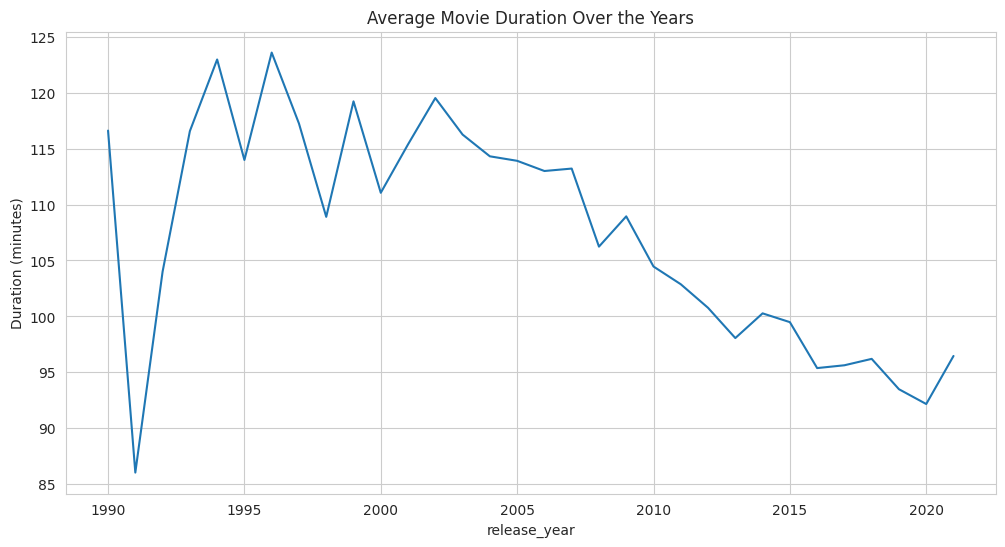

In [23]:
# Average movie duration over years
movies = df[df['type'] == 'Movie']
avg_duration = movies.groupby('release_year')['duration_value'].mean().reset_index()
avg_duration = avg_duration[avg_duration['release_year'] >= 1990]  # focus on recent decades

plt.figure(figsize=(12,6))
sns.lineplot(data=avg_duration, x='release_year', y='duration_value')
plt.title('Average Movie Duration Over the Years')
plt.ylabel('Duration (minutes)')
plt.show()

**5. Text / Categorical Digging**

/tmp/ipykernel_1934/709033321.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_directors.values, y=top_directors.index, palette='flare')


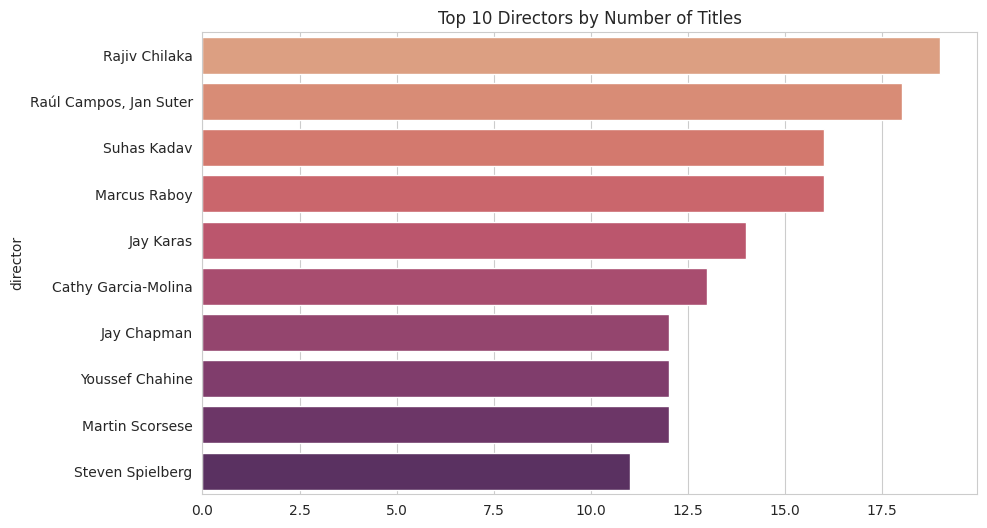

In [24]:
# Most frequent directors (excluding Unknown)
top_directors = df[df['director'] != 'Unknown']['director'].value_counts().head(10)

sns.barplot(x=top_directors.values, y=top_directors.index, palette='flare')
plt.title('Top 10 Directors by Number of Titles')
plt.show()

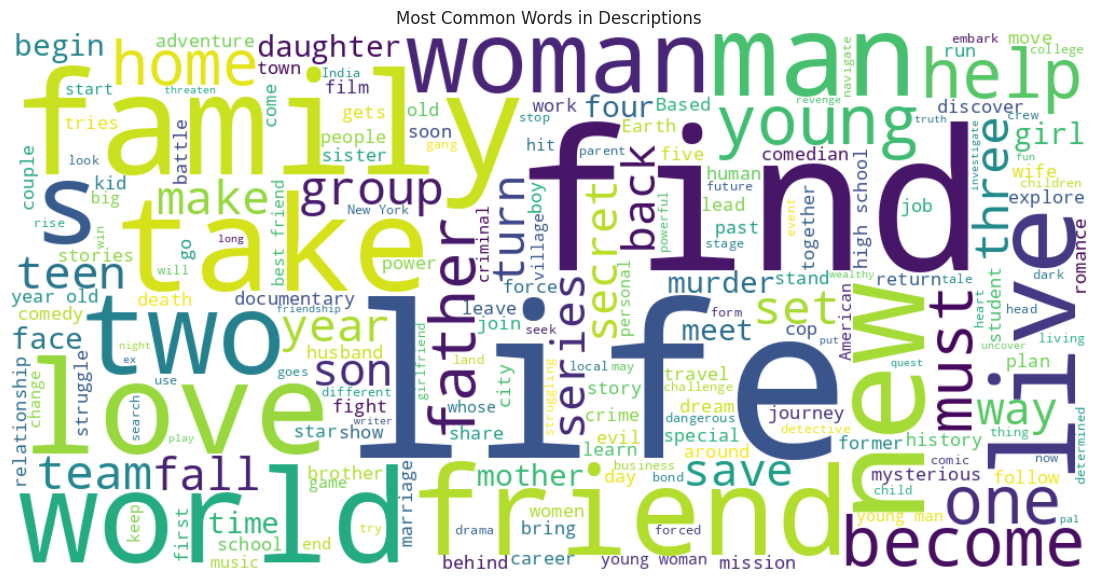

In [25]:
# Word cloud of descriptions
!pip install wordcloud -q
from wordcloud import WordCloud

text = ' '.join(df['description'].dropna())
wc = WordCloud(width=1000, height=500, background_color='white', colormap='viridis').generate(text)

plt.figure(figsize=(14,7))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title('Most Common Words in Descriptions')
plt.show()

**6. Insights Summary**

## Key Insights

- Netflix's content library grew rapidly between 2016–2019, with additions slowing after 2020.
- Movies significantly outnumber TV Shows on the platform overall.
- The US, India, and UK are the top content-producing countries.
- TV-MA and TV-14 are the most common ratings, indicating a skew toward mature audiences.
- International Movies, Dramas, and Comedies are the most common genres.
- Average movie duration has [increased/decreased/stayed stable] — describe based on your actual chart.
- [Add 1-2 more insights specific to what you found]